In [1]:
#environment setup - running list
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colormaps
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
#ADD ABOVE AS NEEDED
import textwrap
import squarify 
import json

import tensorly as tl
from tensorly.decomposition import parafac, tucker

In [2]:
noise=pd.read_csv('nyc_311_noise_complaints_10172025.csv')

C:\Users\matta\AppData\Local\Temp\ipykernel_26804\3940064620.py:1: DtypeWarning: Columns (17,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  noise=pd.read_csv('nyc_311_noise_complaints_10172025.csv')


In [3]:
display(noise.columns, noise.head(5))

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip',
       'incident_address', 'street_name', 'cross_street_1', 'cross_street_2',
       'intersection_street_1', 'intersection_street_2', 'address_type',
       'city', 'landmark', 'status', 'resolution_description',
       'resolution_action_updated_date', 'community_board', 'bbl', 'borough',
       'x_coordinate_state_plane', 'y_coordinate_state_plane',
       'open_data_channel_type', 'park_facility_name', 'park_borough',
       'latitude', 'longitude', 'location', 'vehicle_type', 'facility_type',
       'due_date'],
      dtype='object')

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,incident_zip,incident_address,...,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,vehicle_type,facility_type,due_date
0,63685033,2025-01-08T20:48:29.000,2025-01-08T21:30:04.000,NYPD,New York City Police Department,Noise - Residential,Loud Television,Residential Building/House,11249.0,101 SOUTH 5 STREET,...,198502.0,ONLINE,Unspecified,BROOKLYN,40.711513,-73.964369,"{'latitude': '40.71151337076125', 'longitude':...",NaN,NaN,NaN
1,63685039,2025-01-08T16:15:10.000,2025-01-08T21:27:16.000,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,Residential Building/House,10466.0,655 EAST 230 STREET,...,264242.0,MOBILE,Unspecified,BRONX,40.891872,-73.860168,"{'latitude': '40.89187241649303', 'longitude':...",NaN,NaN,NaN
2,63685040,2025-01-08T00:49:00.000,2025-01-10T05:48:30.000,NYPD,New York City Police Department,Noise - Residential,Loud Talking,Residential Building/House,10010.0,220 EAST 26 STREET,...,208980.0,ONLINE,Unspecified,MANHATTAN,40.740277,-73.980708,"{'latitude': '40.740276831918116', 'longitude'...",NaN,NaN,NaN
3,63685041,2025-01-08T15:29:05.000,2025-01-09T05:14:41.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10458.0,EAST 187 STREET,...,251999.0,PHONE,Unspecified,BRONX,40.858304,-73.892778,"{'latitude': '40.8583040251567', 'longitude': ...",NaN,NaN,NaN
4,63685042,2025-01-08T19:24:41.000,2025-01-09T03:07:12.000,NYPD,New York City Police Department,Noise - Vehicle,Car/Truck Horn,Street/Sidewalk,10462.0,2301 LYON AVENUE,...,244161.0,ONLINE,Unspecified,BRONX,40.836743,-73.849425,"{'latitude': '40.836742557758456', 'longitude'...",Van,NaN,NaN


Creating Date-related features

In [4]:
noise[['created_date','closed_date']] = noise[['created_date','closed_date']].apply(pd.to_datetime) #convert to datetime

noise['resolution_time'] = (noise['closed_date'] - noise['created_date']).dt.total_seconds() / 3600.0  # in hours
noise['created_year'] = noise['created_date'].dt.year
noise['created_month'] = noise['created_date'].dt.month
noise['created_day'] = noise['created_date'].dt.day
noise['created_hour'] = noise['created_date'].dt.hour
noise['created_weekday'] = noise['created_date'].dt.weekday  # Monday=0, Sunday=6
noise['created_weekofyear'] = noise['created_date'].dt.isocalendar().week
noise['created_is_weekend'] = noise['created_weekday'].isin([5, 6]).astype(int)



In [5]:
noise.columns

Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip',
       'incident_address', 'street_name', 'cross_street_1', 'cross_street_2',
       'intersection_street_1', 'intersection_street_2', 'address_type',
       'city', 'landmark', 'status', 'resolution_description',
       'resolution_action_updated_date', 'community_board', 'bbl', 'borough',
       'x_coordinate_state_plane', 'y_coordinate_state_plane',
       'open_data_channel_type', 'park_facility_name', 'park_borough',
       'latitude', 'longitude', 'location', 'vehicle_type', 'facility_type',
       'due_date', 'resolution_time', 'created_year', 'created_month',
       'created_day', 'created_hour', 'created_weekday', 'created_weekofyear',
       'created_is_weekend'],
      dtype='object')

In [6]:
noise_use = noise[['created_date', 'closed_date','resolution_time', 'created_year', 'created_month',
       'created_day', 'created_hour', 'created_weekday', 'created_weekofyear',
       'created_is_weekend', 'complaint_type', 'descriptor','incident_address','community_board']]

In [7]:
noise_use

,created_date,closed_date,resolution_time,created_year,created_month,created_day,created_hour,created_weekday,created_weekofyear,created_is_weekend,complaint_type,descriptor,incident_address,community_board
0,2025-01-08 20:48:29,2025-01-08 21:30:04,0.693056,2025,1,8,20,2,2,0,Noise - Residential,Loud Television,101 SOUTH 5 STREET,01 BROOKLYN
1,2025-01-08 16:15:10,2025-01-08 21:27:16,5.201667,2025,1,8,16,2,2,0,Noise - Residential,Loud Music/Party,655 EAST 230 STREET,12 BRONX
2,2025-01-08 00:49:00,2025-01-10 05:48:30,52.991667,2025,1,8,0,2,2,0,Noise - Residential,Loud Talking,220 EAST 26 STREET,06 MANHATTAN
3,2025-01-08 15:29:05,2025-01-09 05:14:41,13.760000,2025,1,8,15,2,2,0,Noise - Street/Sidewalk,Loud Music/Party,EAST 187 STREET,06 BRONX
4,2025-01-08 19:24:41,2025-01-09 03:07:12,7.708611,2025,1,8,19,2,2,0,Noise - Vehicle,Car/Truck Horn,2301 LYON AVENUE,10 BRONX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2010-10-30 02:30:53,2010-10-30 05:19:31,2.810556,2010,10,30,2,5,43,1,Noise - Residential,Banging/Pounding,8404 BAY PARKWAY,11 BROOKLYN
999996,2010-10-31 00:30:43,2010-10-31 02:08:40,1.632500,2010,10,31,0,6,43,1,Noise - Residential,Loud Music/Party,47 DELANCEY STREET,03 MANHATTAN
999997,2010-10-28 07:04:00,2010-10-29 06:45:00,23.683333,2010,10,28,7,3,43,0,Noise,Noise: Construction Before/After Hours (NM1),32-06 BROADWAY,01 QUEENS
999998,2010-10-29 09:22:01,2010-10-29 13:27:57,4.098889,2010,10,29,9,4,43,0,Noise - Residential,Banging/Pounding,182-25 WEXFORD TERRACE,08 QUEENS


In [13]:
month_ctype_cboard_array.shape

(12, 623)

Let's create a 3rd order tensor based on Month-complaint_type-community board

In [15]:
month_ctype_cboard_df

,created_month,complaint_type,community_board,count
0,1,Collection Truck Noise,0 Unspecified,1
1,1,Collection Truck Noise,01 BRONX,1
2,1,Collection Truck Noise,01 BROOKLYN,1
3,1,Collection Truck Noise,02 BROOKLYN,1
4,1,Collection Truck Noise,02 MANHATTAN,1
...,...,...,...,...
5775,12,Noise - Vehicle,Unspecified BRONX,2
5776,12,Noise - Vehicle,Unspecified BROOKLYN,8
5777,12,Noise - Vehicle,Unspecified MANHATTAN,7
5778,12,Noise - Vehicle,Unspecified QUEENS,6


In [16]:
pivot_month_ctype_cboard

complaint_type  Collection Truck Noise                                    \
community_board          0 Unspecified 01 BRONX 01 BROOKLYN 01 MANHATTAN   
created_month                                                              
1                                  1.0      1.0         1.0          0.0   
2                                  2.0      0.0         0.0          2.0   
3                                  0.0      0.0         1.0          0.0   
4                                  0.0      0.0         0.0          0.0   
5                                  0.0      0.0         0.0          0.0   
6                                  0.0      0.0         0.0          0.0   
7                                  0.0      0.0         0.0          0.0   
8                                  0.0      0.0         0.0          1.0   
9                                  0.0      0.0         0.0          1.0   
10                                 0.0      0.0         0.0          0.0   
11                                 0.0      0.0         0.0          0.0   
12                                 0.0      0.0         0.0          0.0   

complaint_type                                                                \
community_board 01 QUEENS 01 STATEN ISLAND 02 BRONX 02 BROOKLYN 02 MANHATTAN   
created_month                                                                  
1                     0.0              0.0      0.0         1.0          1.0   
2                     0.0              0.0      1.0         2.0          0.0   
3                     0.0              0.0      2.0         1.0          1.0   
4                     0.0              0.0      0.0         0.0          0.0   
5                     0.0              0.0      0.0         0.0          1.0   
6                     0.0              0.0      0.0         0.0          0.0   
7                     0.0              0.0      0.0         0.0          0.0   
8                     1.0              0.0      0.0         0.0          0.0   
9                     1.0              1.0      0.0         0.0          1.0   
10                    0.0              0.0      0.0         0.0          0.0   
11                    0.0              0.0      0.0         0.0          0.0   
12                    0.0              0.0      0.0         0.0          0.0   

complaint_type                    ... Noise - Vehicle                   \
community_board 02 STATEN ISLAND  ...       84 QUEENS 95 STATEN ISLAND   
created_month                     ...                                    
1                            1.0  ...             0.0              0.0   
2                            0.0  ...             0.0              0.0   
3                            0.0  ...             0.0              1.0   
4                            0.0  ...             0.0              0.0   
5                            0.0  ...             0.0              1.0   
6                            0.0  ...             0.0              1.0   
7                            0.0  ...             0.0              0.0   
8                            0.0  ...             0.0              1.0   
9                            1.0  ...             0.0              1.0   
10                           0.0  ...             1.0              0.0   
11                           0.0  ...             0.0              0.0   
12                           0.0  ...             0.0              0.0   

complaint_type                                                                \
community_board Unspecified BRONX Unspecified BROOKLYN Unspecified MANHATTAN   
created_month                                                                  
1                             5.0                  8.0                  17.0   
2                             1.0                  9.0                  14.0   
3                            10.0                 18.0                  16.0   
4                            16.0                 23.0             

In [40]:
month_ctype_cboard_df=noise_use.groupby(['created_month', 'complaint_type', 'community_board']).size().reset_index(name='count')

pivot_month_ctype_cboard = month_ctype_cboard_df.pivot_table(index='created_month', columns=['complaint_type', 'community_board'], values='count', fill_value=0)

X=pivot_month_ctype_cboard.index

Y=pivot_month_ctype_cboard.columns.levels[0]

Z=pivot_month_ctype_cboard.columns.levels[1]

display(X,Y,Z)

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='created_month')

Index(['Collection Truck Noise', 'Noise', 'Noise - Commercial',
       'Noise - Helicopter', 'Noise - House of Worship', 'Noise - Park',
       'Noise - Residential', 'Noise - Street/Sidewalk', 'Noise - Vehicle',
       'Noise Survey'],
      dtype='object', name='complaint_type')

Index(['0 Unspecified', '01 BRONX', '01 BROOKLYN', '01 MANHATTAN', '01 QUEENS',
       '01 STATEN ISLAND', '02 BRONX', '02 BROOKLYN', '02 MANHATTAN',
       '02 QUEENS', '02 STATEN ISLAND', '03 BRONX', '03 BROOKLYN',
       '03 MANHATTAN', '03 QUEENS', '03 STATEN ISLAND', '04 BRONX',
       '04 BROOKLYN', '04 MANHATTAN', '04 QUEENS', '05 BRONX', '05 BROOKLYN',
       '05 MANHATTAN', '05 QUEENS', '06 BRONX', '06 BROOKLYN', '06 MANHATTAN',
       '06 QUEENS', '07 BRONX', '07 BROOKLYN', '07 MANHATTAN', '07 QUEENS',
       '08 BRONX', '08 BROOKLYN', '08 MANHATTAN', '08 QUEENS', '09 BRONX',
       '09 BROOKLYN', '09 MANHATTAN', '09 QUEENS', '10 BRONX', '10 BROOKLYN',
       '10 MANHATTAN', '10 QUEENS', '11 BRONX', '11 BROOKLYN', '11 MANHATTAN',
       '11 QUEENS', '12 BRONX', '12 BROOKLYN', '12 MANHATTAN', '12 QUEENS',
       '13 BROOKLYN', '13 QUEENS', '14 BROOKLYN', '14 QUEENS', '15 BROOKLYN',
       '16 BROOKLYN', '17 BROOKLYN', '18 BROOKLYN', '26 BRONX', '27 BRONX',
       '28 BRONX', '

Needed to account for instances where a complaint_type-community_board combination for a given month never appear so we need to add those back in and fill the value with zero

In [41]:
full_cols = pd.MultiIndex.from_product(
    [Y, Z],
    names=['complaint_type', 'community_board']
)
pivot_month_ctype_cboard = pivot_month_ctype_cboard.reindex(columns=full_cols, fill_value=0)


In [42]:
pivot_month_ctype_cboard_array=pivot_month_ctype_cboard.to_numpy()

pivot_month_ctype_cboard_array=pivot_month_ctype_cboard_array.reshape(len(X), len(Y), len(Z))

month_ctype_cboard_tensor = tl.tensor(pivot_month_ctype_cboard_array)

Axis 0 → created_month

Axis 1 → complaint_type

Axis 2 → community_board

In [44]:
display(len(X), len(Y), len(Z))

12

10

77

In [55]:
# Choose rank (number of latent factors)
rank = 3  

# Run CP decomposition
weights, factors = parafac(tl.tensor(month_ctype_cboard_tensor), rank=rank, n_iter_max=200, tol=1e-6, init='random', random_state=6242)

# Unpack factor matrices
month_factors, complaint_type_factors, community_board_factors = factors
display(month_factors.shape, complaint_type_factors.shape, community_board_factors.shape)
display(month_factors, complaint_type_factors, community_board_factors)
# The shapes of the factor matrices correspond to the dimensions of the original tensor and the chosen rank
# month_factors: (number of months, rank)
# complaint_type_factors: (number of complaint types, rank)
# community_board_factors: (number of community boards, rank)
# Each column in the factor matrices represents a latent factor capturing patterns in the data
# You can analyze these factors to understand the underlying structure of the data

(12, 3)

(10, 3)

(77, 3)

array([[ 9.91406837e+02, -6.57624420e+01,  2.14334467e+00],
       [ 2.34502498e+02, -8.11159267e+01,  3.78675526e+00],
       [ 1.44764841e+02, -1.02419191e+02,  3.75245405e+01],
       [ 9.26797858e+01, -1.10024854e+02,  8.27841455e+01],
       [ 4.32702922e+01, -1.72956668e+02,  1.98020661e+02],
       [ 1.07997548e+02, -1.54060824e+02,  2.46872179e+02],
       [ 8.20014324e+01, -1.08622659e+02,  1.83090527e+02],
       [ 1.39385487e+02, -1.43216784e+02,  2.27364729e+02],
       [ 3.74682105e+02, -1.15795845e+02,  1.43983410e+02],
       [ 6.12215985e+02, -6.26398793e+01,  5.63258855e+01],
       [ 5.98874467e-01, -4.75636984e+00,  6.60037730e-01],
       [ 1.61546411e+00, -1.15555629e+01,  2.58677218e+00]])

array([[-4.24580845e-07, -5.62687584e-04, -1.55651772e-03],
       [-2.50990519e-03, -4.10562616e-01, -7.90235582e-01],
       [-7.35234989e-04, -3.96952882e-01, -4.76387870e-01],
       [-6.45838647e-03, -1.23181403e-01, -3.52939862e-01],
       [ 3.51112523e-04, -1.96265656e-02, -4.76942351e-02],
       [-1.06233130e-03, -2.98961237e-02,  1.09540773e-01],
       [ 2.64575532e+00, -1.83757662e+00, -2.19327361e+00],
       [-3.48902082e-03, -2.87768499e-01,  3.49263651e+00],
       [ 1.55044372e-03, -1.98636262e-01,  2.68493273e-01],
       [-4.94501778e-08, -2.92978655e-07,  1.18224214e-06]])

array([[ 1.49341928e-03,  4.95625644e-02,  7.16965116e-03],
       [ 1.14525160e-01,  3.79119190e+00,  6.59841544e-01],
       [-1.03874583e-01,  7.01320267e+00,  8.84042667e-01],
       [-7.25366504e-02,  2.03310255e+00,  9.11721668e-02],
       [ 4.73289292e-02,  4.98342339e+00,  5.53471041e-01],
       [ 2.09510054e-02,  3.54770241e+00,  7.41989290e-02],
       [ 1.38122398e-02,  2.19240510e+00,  3.65139524e-01],
       [ 4.27752834e-02,  4.36483151e+00,  4.39208876e-01],
       [-7.42176603e-02,  3.01201659e+00,  4.82153867e-01],
       [ 2.33953736e-02,  2.64451155e+00,  2.99118194e-01],
       [-3.73615844e-03,  1.53171585e+00,  5.83969251e-02],
       [ 1.55234044e-01,  5.79752391e+00,  1.39702123e+00],
       [ 1.57308162e-02,  6.37193933e+00,  6.23022776e-01],
       [-2.50959573e-03,  6.07346965e+00,  8.17626345e-01],
       [ 3.14178910e-02,  3.74178587e+00,  3.66686038e-01],
       [-2.84029048e-02,  1.51201176e+00,  3.45456773e-04],
       [ 1.04844876e-01,  8.14810692e+00

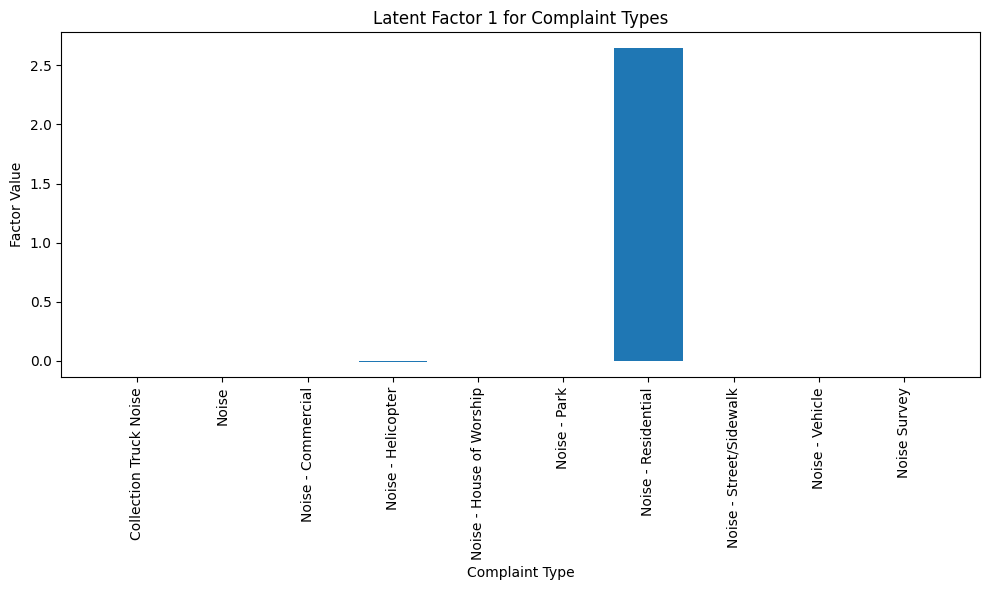

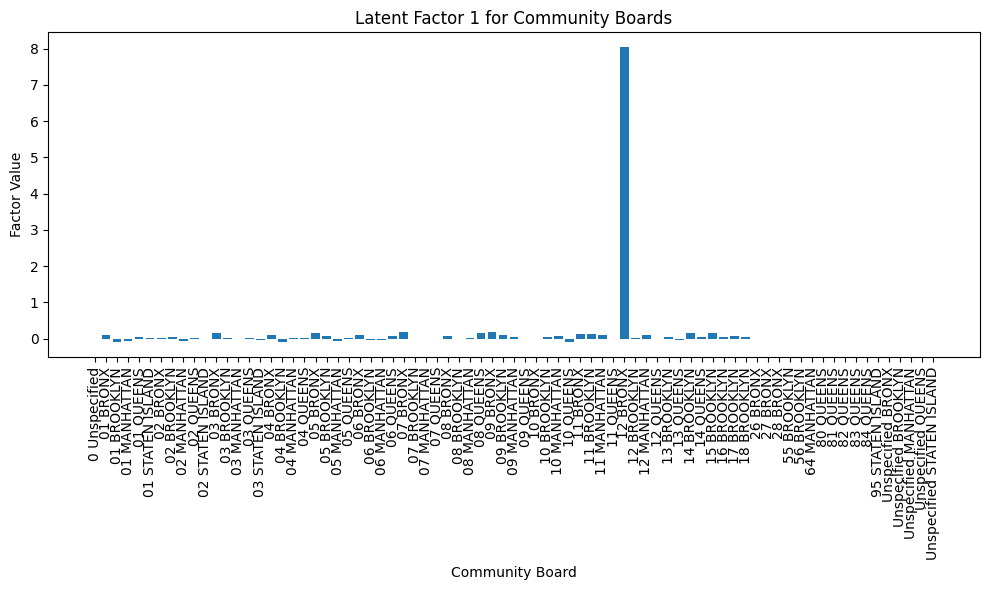

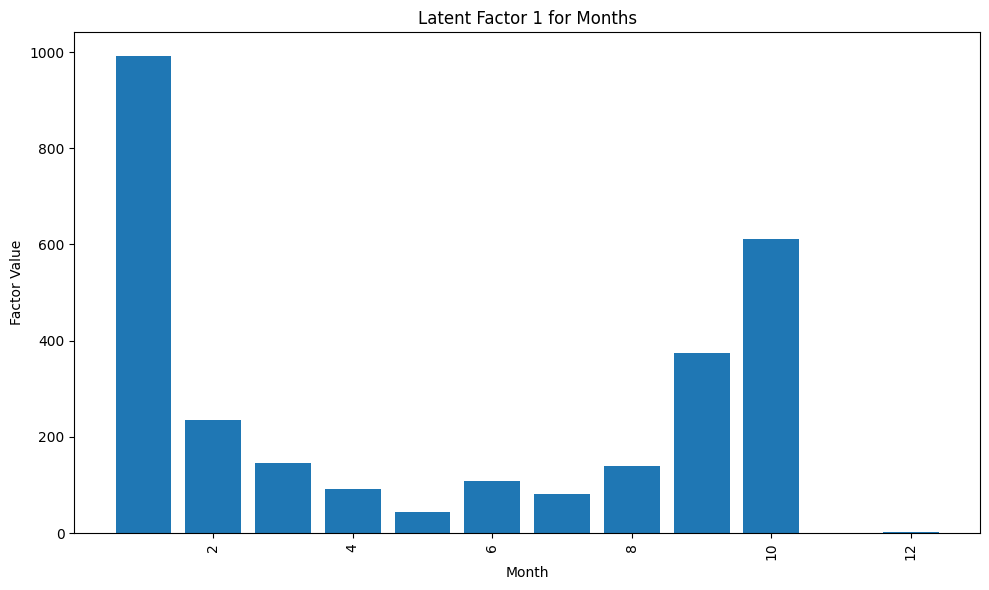

In [58]:
import matplotlib.pyplot as plt

# Visualize the first latent factor for complaint types
plt.figure(figsize=(10, 6))
plt.bar(Y, complaint_type_factors[:, 0])
plt.xlabel('Complaint Type')
plt.ylabel('Factor Value')
plt.title('Latent Factor 1 for Complaint Types')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Visualize the first latent factor for community boards
plt.figure(figsize=(10, 6))
plt.bar(Z, community_board_factors[:, 0])
plt.xlabel('Community Board')
plt.ylabel('Factor Value')
plt.title('Latent Factor 1 for Community Boards')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Visualize the first latent factor for months
plt.figure(figsize=(10, 6))
plt.bar(X, month_factors[:, 0])
plt.xlabel('Month')
plt.ylabel('Factor Value')
plt.title('Latent Factor 1 for Months')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#The higher the value, the more that complaint type/community board/month contributes to that latent factor

In [59]:
# You can repeat the visualization for other latent factors by changing the index in complaint_type_factors[:, i], community_board_factors[:, i], and month_factors[:, i] where i is the factor index (0, 1, 2, ... rank-1).
# Needed to account for instances where a complaint_type-community_board combination for a given month never appear so we need to add those back in and fill the value with zero
